In [1]:
# ==========================================================
# LIBRERÍAS BASE PARA MANEJO Y PROCESAMIENTO DE DATOS
# ==========================================================

import pandas as pd              # Manipulación y análisis de datos estructurados (DataFrames)
import numpy as np               # Operaciones numéricas y manejo eficiente de arreglos
import random                    # Generación de aleatoriedad para exploración en RL
from collections import deque    # Buffer eficiente para experiencia (Replay Memory)
import optuna                    # Optimizador de hiperparámetros
import tensorflow as tf

# ==========================================================
# PREPROCESAMIENTO Y DIVISIÓN DE DATOS
# ==========================================================

from sklearn.preprocessing import StandardScaler      # Normalización de variables para estabilizar el entrenamiento
from sklearn.model_selection import train_test_split  # Separación de datos en entrenamiento y prueba


# ==========================================================
# MODELADO CON DEEP LEARNING (Keras / TensorFlow)
# ==========================================================

from tensorflow.keras.models import Sequential      # Arquitectura secuencial para construir la red neuronal
from tensorflow.keras.layers import Dense, Dropout, LSTM  # Capas fully-connected, regularización y memoria temporal
from tensorflow.keras.optimizers import Adam        # Optimizador adaptativo para entrenamiento eficiente
from tensorflow.keras.callbacks import ModelCheckpoint  # Guardado automático del mejor modelo durante entrenamiento

C:\Users\PC\anaconda3\envs\tf_gpu\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
# ======================================================================
# CARGA Y VALIDACIÓN INICIAL DEL DATASET
# ======================================================================

# Ruta del archivo (recomendable parametrizar en versiones productivas)
DATA_PATH = "Gold-Silver-GeopoliticalRisk_HistoricalData.csv"

# Carga del dataset histórico
df = pd.read_csv(DATA_PATH)

# Verificación básica de integridad estructural
print("Dimensiones del dataset (filas, columnas):", df.shape)

# Visualización preliminar de registros
df.head()

Dimensiones del dataset (filas, columnas): (10571, 15)


,DATE,GOLD_PRICE,GOLD_OPEN,GOLD_HIGH,GOLD_LOW,GOLD_CHANGE_%,SILVER_PRICE,SILVER_OPEN,SILVER_HIGH,SILVER_LOW,SILVER_CHANGE_%,GPRD,GPRD_ACT,GPRD_THREAT,EVENT
0,2025-09-10,3630.90,3633.61,3634.42,3620.90,-0.07,40.92,40.89,40.94,40.72,0.09,NaN,NaN,NaN,NaN
1,2025-09-09,3633.61,3637.10,3674.75,3625.33,-0.06,40.89,41.34,41.50,40.77,-1.13,NaN,NaN,NaN,NaN
2,2025-09-08,3635.84,3586.82,3646.60,3579.67,1.24,41.36,41.01,41.68,40.51,1.20,117.26,97.42,146.26,NaN
3,2025-09-07,3591.19,3592.07,3596.56,3586.95,0.12,40.86,41.00,41.01,40.76,-0.34,83.51,111.00,92.59,NaN
4,2025-09-05,3586.81,3547.00,3600.33,3540.05,1.15,41.01,40.69,41.44,40.55,0.76,166.42,110.61,224.05,NaN


In [3]:
# ==========================================================
# INSPECCIÓN INICIAL
# ==========================================================

print("Resumen estructural del dataset:")
df.info()

print("\nEstadísticas descriptivas de variables numéricas:")
df.describe()

Resumen estructural del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10571 entries, 0 to 10570
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   DATE             10571 non-null  object 
 1   GOLD_PRICE       10571 non-null  float64
 2   GOLD_OPEN        10571 non-null  float64
 3   GOLD_HIGH        10571 non-null  float64
 4   GOLD_LOW         10571 non-null  float64
 5   GOLD_CHANGE_%    10571 non-null  float64
 6   SILVER_PRICE     10564 non-null  float64
 7   SILVER_OPEN      10564 non-null  float64
 8   SILVER_HIGH      10564 non-null  float64
 9   SILVER_LOW       10564 non-null  float64
 10  SILVER_CHANGE_%  10564 non-null  float64
 11  GPRD             10569 non-null  float64
 12  GPRD_ACT         10569 non-null  float64
 13  GPRD_THREAT      10569 non-null  float64
 14  EVENT            11 non-null     object 
dtypes: float64(13), object(2)
memory usage: 1.2+ MB

Estadísticas descripti

,GOLD_PRICE,GOLD_OPEN,GOLD_HIGH,GOLD_LOW,GOLD_CHANGE_%,SILVER_PRICE,SILVER_OPEN,SILVER_HIGH,SILVER_LOW,SILVER_CHANGE_%,GPRD,GPRD_ACT,GPRD_THREAT
count,10571.000000,10571.000000,10571.000000,10571.000000,10571.000000,10564.000000,10564.000000,10564.000000,10564.000000,10564.000000,10569.000000,10569.000000,10569.000000
mean,887.276856,887.412518,892.378187,881.901980,0.028118,12.825364,12.810967,12.967795,12.664810,0.033753,110.456114,106.908445,113.966142
std,666.189751,665.535068,671.811142,659.998671,0.976355,9.189963,9.184530,9.353250,9.010104,1.734102,62.347401,94.018143,65.015038
min,252.550000,252.350000,252.550000,252.550000,-8.490000,3.540000,3.530000,3.540000,3.530000,-20.540000,9.490000,0.000000,0.000000
25%,361.075000,362.150000,361.075000,361.075000,-0.430000,5.130000,5.130000,5.130000,5.130000,-0.750000,74.880000,58.240000,72.120000
50%,462.350000,464.620000,462.350000,462.350000,0.010000,7.635000,7.620000,7.635000,7.630000,0.000000,98.590000,88.240000,100.620000
75%,1312.045000,1312.345000,1320.130000,1305.395000,0.500000,18.140000,18.130000,18.395000,17.910000,0.880000,131.060000,130.360000,139.720000
max,3635.840000,3637.100000,3674.750000,3625.330000,11.000000,48.450000,48.420000,49.550000,47.520000,14.870000,1045.600000,1627.430000,809.490000


In [4]:
# ==========================================================
# VERIFICACIÓN DE VALORES NULOS Y DUPLICADOS
# ==========================================================

print("Valores nulos por columna:\n", df.isnull().sum())
print("Duplicados:", df.duplicated().sum())

Valores nulos por columna:
 DATE                   0
GOLD_PRICE             0
GOLD_OPEN              0
GOLD_HIGH              0
GOLD_LOW               0
GOLD_CHANGE_%          0
SILVER_PRICE           7
SILVER_OPEN            7
SILVER_HIGH            7
SILVER_LOW             7
SILVER_CHANGE_%        7
GPRD                   2
GPRD_ACT               2
GPRD_THREAT            2
EVENT              10560
dtype: int64
Duplicados: 0


In [5]:
# ==========================================================
# CONVERSIÓN Y ORDENAMIENTO TEMPORAL
# ==========================================================

# Convertir fecha a datetime
df["DATE"] = pd.to_datetime(df["DATE"])

# Ordenar cronológicamente
df = df.sort_values("DATE").reset_index(drop=True)

df.head()

,DATE,GOLD_PRICE,GOLD_OPEN,GOLD_HIGH,GOLD_LOW,GOLD_CHANGE_%,SILVER_PRICE,SILVER_OPEN,SILVER_HIGH,SILVER_LOW,SILVER_CHANGE_%,GPRD,GPRD_ACT,GPRD_THREAT,EVENT
0,1985-01-02,305.5,305.5,305.5,305.5,-0.91,6.15,6.15,6.15,6.15,-3.30,115.68,146.77,87.44,NaN
1,1985-01-03,302.3,302.3,302.3,302.3,-1.05,6.09,6.09,6.09,6.09,-0.98,97.43,158.94,29.46,NaN
2,1985-01-04,303.1,303.1,303.1,303.1,0.26,6.03,6.03,6.03,6.03,-0.99,157.37,156.88,157.03,NaN
3,1985-01-07,298.2,298.2,298.2,298.2,-1.62,5.80,5.80,5.80,5.80,-3.81,105.31,57.27,143.30,NaN
4,1985-01-08,302.0,302.0,302.0,302.0,1.27,6.01,6.01,6.01,6.01,3.62,87.40,34.85,130.82,NaN


In [6]:
# ==========================================================
# SELECCIÓN DE VARIABLES RELEVANTES
# ==========================================================

df = df.drop(columns=[
    "GOLD_OPEN","GOLD_HIGH","GOLD_LOW","GOLD_CHANGE_%",
    "SILVER_OPEN","SILVER_HIGH","SILVER_LOW","SILVER_CHANGE_%",
    "GPRD_ACT","GPRD_THREAT","EVENT"
])

df.head()

,DATE,GOLD_PRICE,SILVER_PRICE,GPRD
0,1985-01-02,305.5,6.15,115.68
1,1985-01-03,302.3,6.09,97.43
2,1985-01-04,303.1,6.03,157.37
3,1985-01-07,298.2,5.80,105.31
4,1985-01-08,302.0,6.01,87.40


In [7]:
def imputar_por_mejor_vecino(df, col_x, col_y):

    """
    Imputa valores faltantes en col_x utilizando el vecino
    (anterior o siguiente) cuya variable col_y sea más similar.
    
    Requiere que el DataFrame esté ordenado cronológicamente.
    """
    
    df = df.copy()

    for idx in df[df[col_x].isna()].index:
        valor_y_actual = df.loc[idx, col_y]

        candidatos = []

        # Vecino anterior
        if idx - 1 >= 0 and not pd.isna(df.loc[idx - 1, col_x]):
            diff_prev = abs(valor_y_actual - df.loc[idx - 1, col_y])
            candidatos.append((diff_prev, df.loc[idx - 1, col_x]))

        # Vecino siguiente
        if idx + 1 < len(df) and not pd.isna(df.loc[idx + 1, col_x]):
            diff_next = abs(valor_y_actual - df.loc[idx + 1, col_y])
            candidatos.append((diff_next, df.loc[idx + 1, col_x]))

        # Selección del mejor candidato
        if candidatos:
            _, mejor_valor = min(candidatos, key=lambda x: x[0])
            df.loc[idx, col_x] = mejor_valor

    return df

In [8]:
imputar_por_mejor_vecino(df, 'SILVER_PRICE', 'GPRD')
df = df.dropna()
df.isna().sum()

DATE            0
GOLD_PRICE      0
SILVER_PRICE    0
GPRD            0
dtype: int64

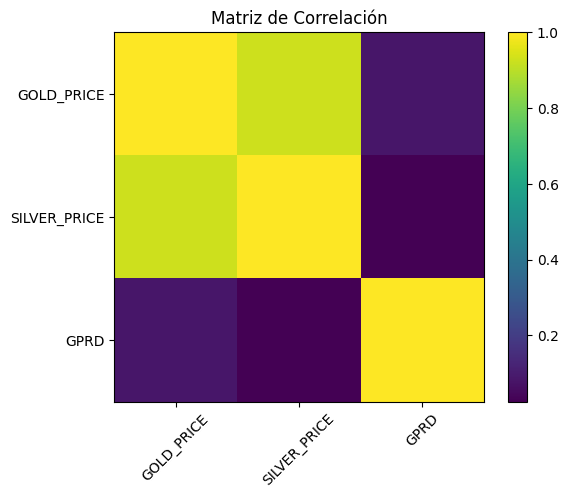

In [9]:
# ==========================================================
# ANÁLISIS DE CORRELACIÓN
# ==========================================================

import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure()
plt.imshow(corr)
plt.title("Matriz de Correlación")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()


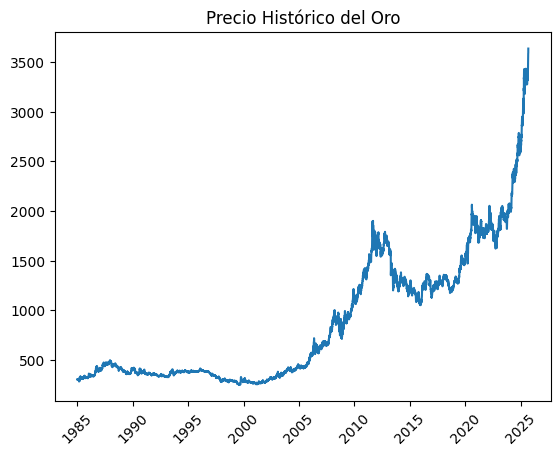

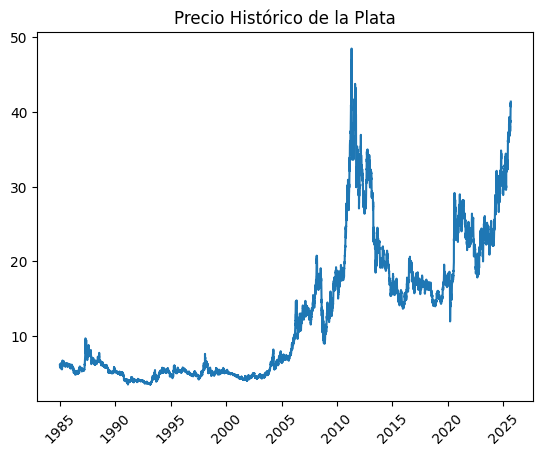

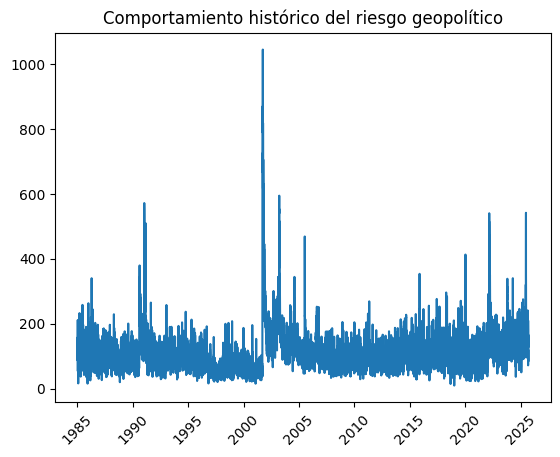

In [10]:
# ==========================================================
# VISUALIZACIÓN DE SERIES TEMPORALES
# ==========================================================

plt.figure()
plt.plot(df["DATE"], df["GOLD_PRICE"])
plt.title("Precio Histórico del Oro")
plt.xticks(rotation=45)
plt.show()

plt.figure()
plt.plot(df["DATE"], df["SILVER_PRICE"])
plt.title("Precio Histórico de la Plata")
plt.xticks(rotation=45)
plt.show()

plt.figure()
plt.plot(df["DATE"], df["GPRD"])
plt.title("Comportamiento histórico del riesgo geopolítico")
plt.xticks(rotation=45)
plt.show()

In [11]:
# ==========================================================
# DIVISIÓN TEMPORAL TRAIN / TEST
# ==========================================================
# Asegurar que esté ordenado por fecha
df = df.sort_values("DATE").reset_index(drop=True)

# Creación de retornos
df["ret_gold"] = np.log(df["GOLD_PRICE"] / df["GOLD_PRICE"].shift(1))
df["ret_silver"] = np.log(df["SILVER_PRICE"] / df["SILVER_PRICE"].shift(1))
df["spread"] = np.log(df["GOLD_PRICE"]) - np.log(df["SILVER_PRICE"])
df["spread_z"] = (df["spread"] - df["spread"].rolling(30).mean()) / df["spread"].rolling(30).std()

# Creación de retornos para target
df["ret_oro_fut"] = df["ret_gold"].shift(-1)
df["ret_plata_fut"] = df["ret_silver"].shift(-1)

In [12]:
# ==========================================================
# ACCIONES POR ACTIVO
# ==========================================================

# Definición de umbral
threshold = 0.002

# Función auxiliar
def action(x):
    if x > threshold:
        return 2   # Comprar
    elif x < -threshold:
        return 0   # Vender
    else:
        return 1   # Mantener

df["act_gold"] = df["ret_oro_fut"].apply(action)
df["act_silver"] = df["ret_plata_fut"].apply(action)

In [13]:
# ==========================================================
# CREACIÓN DE CLASE CONJUNTA
# ==========================================================
df["target"] = df["act_gold"] * 3 + df["act_silver"]
df = df.dropna().reset_index(drop=True)

In [14]:
df["target"].value_counts(normalize=True)

target
8    0.300418
0    0.269180
5    0.096848
3    0.088872
4    0.063806
2    0.046620
6    0.045480
7    0.045385
1    0.043392
Name: proportion, dtype: float64

In [15]:
# ==========================================================
# DEFINICIÓN DE FEATURES
# ==========================================================
features = ["ret_gold", "ret_silver", "GPRD"]
X_all = df[features].values
y_all = df["target"].values

In [16]:
# ==========================================================
# CREACIÓN DE SECUENCIAS LSTM
# ==========================================================
def create_sequences(X, y, window_size):
    X_seq, y_seq = [], []
    
    for i in range(window_size, len(X)):
        X_seq.append(X[i-window_size:i])
        y_seq.append(y[i])
    
    return np.array(X_seq), np.array(y_seq)

In [17]:
# =========================
# CONFIGURACIÓN GENERAL
# =========================

INITIAL_BUDGET = 1000.0

FEATURES = 12
WINDOW_SIZE = 100

STATE_SIZE = (WINDOW_SIZE, FEATURES)
ACTION_SIZE = 5

GAMMA = 0.95
EPSILON = 1.0
EPSILON_MIN = 0.01
EPSILON_DECAY = 0.995
LR = 0.001

MEMORY_SIZE = 3000
BATCH_SIZE = 32

# =========================
# MODELO LSTM
# =========================

def build_lstm_model():
    model = Sequential()

    model.add(LSTM(64, input_shape=STATE_SIZE, return_sequences=True))
    model.add(Dropout(0.2))  # anti-overfitting

    model.add(LSTM(64))
    model.add(Dropout(0.2))

    model.add(Dense(32, activation='relu'))
    model.add(Dense(ACTION_SIZE, activation='linear'))

    model.compile(optimizer=Adam(learning_rate=LR),loss='mse')

    return model

# =========================
# AGENTE
# =========================

class TradingAgent:
    def __init__(self):
        self.memory = deque(maxlen=MEMORY_SIZE)
        self.epsilon = EPSILON
        self.model = build_lstm_model()
    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))
    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(ACTION_SIZE)

        q_values = self.model.predict(state, verbose=0)
        return np.argmax(q_values[0])

# =========================
# ENTORNO DE TRADING
# =========================

class TradingEnvironment:
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
        self.reset()

    def reset(self):
        self.portfolio_value = INITIAL_BUDGET
        self.step_idx = WINDOW_SIZE
        self.cash = INITIAL_BUDGET
        self.gold_units = 0.0
        self.silver_units = 0.0
        self.prev_value = INITIAL_BUDGET
        return self._get_state()

    def _get_state(self):
        window = []

        portfolio_value = (
            self.cash +
            self.gold_units * self.df.iloc[self.step_idx]['GOLD_PRICE'] +
            self.silver_units * self.df.iloc[self.step_idx]['SILVER_PRICE']
        )

        for i in range(self.step_idx - WINDOW_SIZE, self.step_idx):

            row = self.df.iloc[i]

            gold_value = self.gold_units * row['GOLD_PRICE']
            silver_value = self.silver_units * row['SILVER_PRICE']

            cash_ratio = self.cash / portfolio_value if portfolio_value > 0 else 0
            gold_ratio = gold_value / portfolio_value if portfolio_value > 0 else 0
            silver_ratio = silver_value / portfolio_value if portfolio_value > 0 else 0

            window.append([
                row['ret_gold'],
                row['ret_silver'],
                row['spread_z'],
                cash_ratio,
                gold_ratio,
                silver_ratio
            ])

        return np.array([window])

    def step(self, action):
        row = self.df.iloc[self.step_idx]

        gold_price = row['GOLD_PRICE']
        silver_price = row['SILVER_PRICE']

        # ===== ACCIONES =====
        if action == 0 and self.cash >= gold_price:
            units = self.cash / gold_price
            self.gold_units += units
            self.cash = 0

        elif action == 1 and self.cash >= silver_price:
            units = self.cash / silver_price
            self.silver_units += units
            self.cash = 0

        elif action == 2:
            self.cash += self.gold_units * gold_price
            self.gold_units = 0

        elif action == 3:
            self.cash += self.silver_units * silver_price
            self.silver_units = 0

        elif action == 4:
            pass  # esperar

        self.portfolio_value = (
            self.cash + 
            self.gold_units * gold_price + 
            self.silver_units * silver_price
        )

        reward = np.log(self.portfolio_value / self.prev_value)
        self.prev_value = self.portfolio_value
        
        self.step_idx += 1
        done = self.step_idx >= len(self.df)
        if done:
            next_state = None
        else:
            next_state = self._get_state()
        
        return next_state, reward, done

    # ===== REPLAY =====
    def replay(self):
        if len(self.memory) < BATCH_SIZE:
            return

        minibatch = random.sample(self.memory, BATCH_SIZE)

        states = []
        targets = []

        for state, action, reward, next_state, done in minibatch:

            target = reward

            if not done:
                next_q = np.amax(self.model.predict(next_state, verbose=0)[0])
                target = reward + GAMMA * next_q

            target_f = self.model.predict(state, verbose=0)
            target_f[0][action] = target

            states.append(state[0])
            targets.append(target_f[0])

        self.model.fit(
            np.array(states),
            np.array(targets),
            epochs=1,
            verbose=0
        )
        if self.epsilon > EPSILON_MIN:
            self.epsilon *= EPSILON_DECAY

# =========================
# ENTRENAMIENTO
# =========================

def train_agent(df, episodes=10):
    env = TradingEnvironment(df)
    agent = TradingAgent()

    checkpoint = ModelCheckpoint(
        filepath="best_trading_lstm_model.h5",
        monitor="loss",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    )

    
    for e in range(episodes):
        state = env.reset()
        total_reward = 0

        while True:
            action = agent.act(state)
            next_state, reward, done = env.step(action)

            agent.remember(state, action, reward, next_state, done)
            agent.replay() 
            state = next_state
            total_reward += reward

            if done:
                break

        print(
            f"Episode {e+1}/{episodes} | "
            f"Reward: {round(total_reward,2)} | "
            f"Epsilon: {round(agent.epsilon,4)}"
        )
    # Guardar checkpoint manualmente
        agent.model.save(
            f"checkpoint_episode_{e+1}.h5"
        )
    return agent



In [18]:
def evaluate_agent(df, agent):

    env = TradingEnvironment(df)
    state = env.reset()

    returns = []

    while True:
        action = agent.act(state)
        next_state, reward, done = env.step(action)

        returns.append(reward)
        state = next_state

        if done:
            break

    returns = np.array(returns)

    sharpe = np.mean(returns) / (np.std(returns) + 1e-8)

    return sharpe, returns

In [19]:
def prepare_data(data, window_size=WINDOW_SIZE):

    states = []
    targets = []

    for i in range(window_size, len(data)):
        states.append(data[i-window_size:i])
        targets.append(data[i, 1])  # si la columna 0 es el target

    return np.array(states), np.array(targets)

In [20]:
def mix_old_new(old_states, old_targets,
                new_states, new_targets,
                ratio=0.3):

    if len(old_states) == 0:
        return new_states, new_targets

    n_old = int(len(new_states) * ratio)

    if n_old > len(old_states):
        n_old = len(old_states)

    idx = np.random.choice(len(old_states), n_old, replace=False)

    mixed_states = np.concatenate([new_states, old_states[idx]], axis=0)
    mixed_targets = np.concatenate([new_targets, old_targets[idx]], axis=0)

    return mixed_states, mixed_targets

In [21]:
def evaluate(model, test_states, test_targets):

    predictions = model.predict(test_states, verbose=0).flatten()

    # Asegurar misma longitud
    min_len = min(len(predictions), len(test_targets))

    predictions = predictions[:min_len]
    test_targets = test_targets[:min_len]

    signals = np.sign(predictions)
    strategy_returns = signals * test_targets

    cumulative_return = np.sum(strategy_returns)

    mean_return = np.mean(strategy_returns)
    volatility = np.std(strategy_returns)

    sharpe = mean_return / volatility if volatility != 0 else 0

    return {
        "cumulative_return": cumulative_return,
        "sharpe": sharpe
    }


In [22]:

def incremental_fine_tune(model,
                          train_states,
                          train_targets,
                          epochs=5,
                          batch_size=32,
                          lr_decay=None,
                          verbose=0):

    callbacks = []

    # Si se define lr_decay, aplicar scheduler
    if lr_decay is not None:
        def scheduler(epoch, lr):
            return lr * lr_decay

        callbacks.append(
            tf.keras.callbacks.LearningRateScheduler(scheduler, verbose=0)
        )

    history = model.fit(
        train_states,
        train_targets,
        epochs=epochs,
        batch_size=batch_size,
        shuffle=False,
        callbacks=callbacks,
        verbose=verbose
    )

    return model, history

In [23]:
#===========================================================
# WALK-FORWARD VALIDATION MEJORADO CON TEST ESCALADO
# ==========================================================
def walk_forward_training(df,
                          agent,
                          window_size,
                          step_size,
                          initial_train_size,
                          scaler_class,
                          full_epochs=50,
                          incremental_epochs=5):

    results = []
    prev_states, prev_targets = None, None

    all_test_dfs = []      # Para inspección final (fechas, columnas)
    all_test_states = []   # Para evaluación del modelo
    all_test_targets = []  # Para evaluación del modelo

    start = 0
    end_train = initial_train_size
    fold = 0

    while end_train + step_size < len(df):

        print(f"\n===== FOLD {fold} =====")

        train_df = df[start:end_train].copy()
        test_df  = df[end_train:end_train + step_size].copy()

        # Guardamos test_df original
        all_test_dfs.append(test_df.copy())

        # Solo columnas numéricas para entrenamiento
        train_numeric = train_df.select_dtypes(include=[np.number])
        test_numeric  = test_df.select_dtypes(include=[np.number])

        # =========================
        # ESCALAMIENTO CORRECTO
        # =========================
        scaler = scaler_class()
        train_scaled = scaler.fit_transform(train_numeric)
        test_scaled  = scaler.transform(test_numeric)

        # =========================
        # PREPARAR DATOS
        # =========================
        train_states, train_targets = prepare_data(train_scaled)
        test_states, test_targets   = prepare_data(test_scaled)

        # =========================
        # ENTRENAMIENTO
        # =========================
        if fold == 0:
            print("Entrenamiento inicial completo")
            history = agent.fit(
                train_states,
                train_targets,
                epochs=full_epochs,
                batch_size=32,
                verbose=1
            )
            results.append({"fold": fold, "loss": history.history['loss']})
        else:
            print("Fine-tuning incremental")

            # Mezclar memoria pasada si existe
            if prev_states is not None:
                train_states, train_targets = mix_old_new(
                    prev_states,
                    prev_targets,
                    train_states,
                    train_targets,
                    ratio=0.3
                )

            agent, history = incremental_fine_tune(
                agent,
                train_states,
                train_targets,
                epochs=incremental_epochs,
                batch_size=32,
                lr_decay=0.5
            )

        # =========================
        # EVALUACIÓN
        # =========================
        evaluation = evaluate(agent, test_states, test_targets)
        results.append(evaluation)

        # Guardar para siguiente fold
        prev_states, prev_targets = train_states, train_targets

        # Acumular test_states y test_targets
        all_test_states.append(test_states)
        all_test_targets.append(test_targets)

        # Avanzar ventana
        end_train += step_size
        fold += 1

    # =========================
    # CONCATENAR TODO EL TEST PARA EVALUACIÓN FINAL
    # =========================
    test_states_full  = np.concatenate(all_test_states, axis=0)
    test_targets_full = np.concatenate(all_test_targets, axis=0)
    test_df_full      = pd.concat(all_test_dfs).reset_index(drop=True)

    return results, test_df_full, test_states_full, test_targets_full

In [24]:
# ==========================================
# CONSTRUCCIÓN DEL AGENTE
# ==========================================
agent = build_lstm_model()

# ==========================================
# EJECUCIÓN WALK-FORWARD
# ==========================================
results, test_df_full, test_states_full, test_targets_full = walk_forward_training(
    df=df,
    agent=agent,
    window_size=WINDOW_SIZE,
    step_size=200,              # tamaño del bloque de test
    initial_train_size=1000,    # entrenamiento inicial
    scaler_class=StandardScaler,
    full_epochs=50,
    incremental_epochs=5
)


===== FOLD 0 =====
Entrenamiento inicial completo
Epoch 1/50
29/29 [==============================] - 4s 14ms/step - loss: 0.5462
Epoch 2/50
29/29 [==============================] - 0s 13ms/step - loss: 0.1030
Epoch 3/50
29/29 [==============================] - 0s 13ms/step - loss: 0.0512
Epoch 4/50
29/29 [==============================] - 0s 13ms/step - loss: 0.0396
Epoch 5/50
29/29 [==============================] - 0s 13ms/step - loss: 0.0315
Epoch 6/50
29/29 [==============================] - 0s 13ms/step - loss: 0.0264
Epoch 7/50
29/29 [==============================] - 0s 13ms/step - loss: 0.0268
Epoch 8/50
29/29 [==============================] - 0s 14ms/step - loss: 0.0234
Epoch 9/50
29/29 [==============================] - 0s 14ms/step - loss: 0.0207
Epoch 10/50
29/29 [==============================] - 0s 14ms/step - loss: 0.0198
Epoch 11/50
29/29 [==============================] - 0s 14ms/step - loss: 0.0190
Epoch 12/50
29/29 [==============================] - 0s 14ms/step -

KeyError: 'loss'

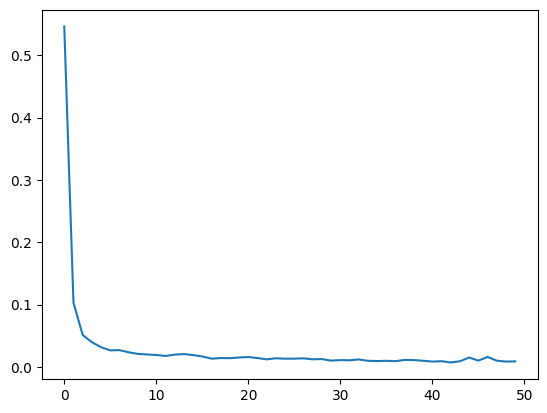

In [25]:
plt.figure()

for r in results:
    plt.plot(list(map(float,r["loss"])), label=f'Fold {r["fold"]}')

plt.title("Walk-Forward Training Loss per Fold")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
agent.save("trading_lstm_dqn.h5")

In [27]:
from tensorflow.keras.models import load_model


model = load_model("trading_lstm_dqn.h5")

In [28]:
def test_agent(agent, test_df):

    env_test = TradingEnvironment(test_df)
    state = env_test.reset()

    total_reward = 0
    rewards = []
    equity_curve = []

    done = False

    while not done:

        state_input = state   # tu estado ya tiene forma (1, window, features)

        q_values = agent.predict(state_input, verbose=0)
        action = np.argmax(q_values[0])

        next_state, reward, done = env_test.step(action)

        total_reward += reward
        rewards.append(reward)

        portfolio_value = (
            env_test.cash +
            env_test.gold_units * env_test.df.iloc[env_test.step_idx-1]['GOLD_PRICE'] +
            env_test.silver_units * env_test.df.iloc[env_test.step_idx-1]['SILVER_PRICE']
        )

        equity_curve.append(portfolio_value)

        if done:
            break

        state = next_state

In [31]:
evaluation = test_agent(agent, test_df_full)

results.append({
    "loss": history.history["loss"],
    "total_reward": evaluation["total_reward"],
    "equity_curve": evaluation["equity_curve"]
})

NameError: name 'history' is not defined

In [ ]:
import matplotlib.pyplot as plt

plt.plot(results["equity_curve"])
plt.title("Out-of-Sample Equity Curve")
plt.show()